RAW DATA:
                                    name       price 24h_change 7d_change  \
0   Bitcoin                          BTC  $74,716.05       1.2%      5.0%   
1  Ethereum                          ETH   $2,292.37       2.3%      4.6%   
2   Tether                          USDT       $1.00       0.0%      0.0%   
3       XRP                          XRP       $1.41       1.5%      5.9%   
4       BNB                          BNB     $622.65       0.9%      4.5%   

        market_cap              volume  
0  $56,080,023,925  $1,495,417,056,556  
1  $17,592,255,408    $276,646,264,225  
2  $84,674,307,859    $187,277,738,561  
3   $2,193,868,522     $86,843,529,341  
4   $1,018,991,587     $83,924,655,555  
Shape: (48, 6)

CLEANED DATA:
                                    name     price  24h_change  7d_change  \
0   Bitcoin                          BTC  74716.05         1.2        5.0   
1  Ethereum                          ETH   2292.37         2.3        4.6   
2   Tether          

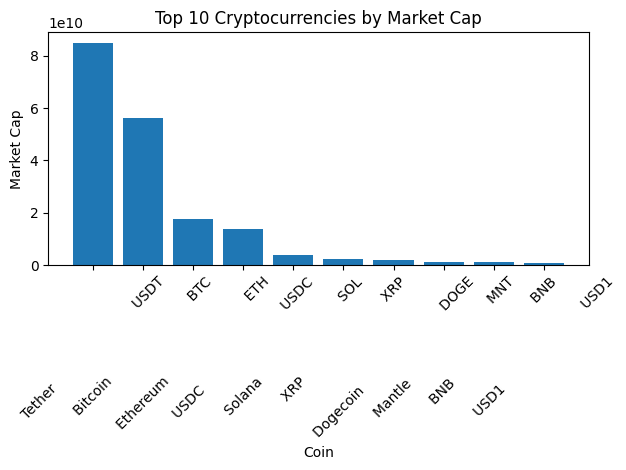

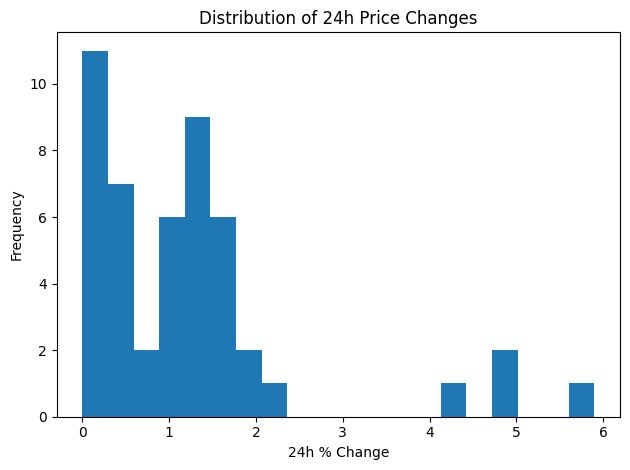

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Request page
# -------------------------------
url = "https://www.coingecko.com/en"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# -------------------------------
# Step 2: Extract data (FINAL FIX)
# -------------------------------
rows = soup.find("tbody").find_all("tr")

data = []

for row in rows[:50]:
    cols = row.find_all("td")

    try:
        # Name
        name = cols[2].text.strip().replace("\n", " ")

        # Extract all cell text
        values = [col.text.strip() for col in cols]

        # Extract dollar values (correct source of price, market cap, volume)
        dollar_values = [v for v in values if "$" in v]

        # Extract percentage values
        percent_values = [v for v in values if "%" in v]

        # Assign correctly
        price = dollar_values[0]
        market_cap = dollar_values[1]
        volume = dollar_values[2]

        # Correct percentage positions (skip 1h change)
        change_24h = percent_values[1]
        change_7d = percent_values[2]

        data.append({
            "name": name,
            "price": price,
            "24h_change": change_24h,
            "7d_change": change_7d,
            "market_cap": market_cap,
            "volume": volume
        })

    except:
        continue

df = pd.DataFrame(data)

# Save raw data
df.to_csv("coingecko_raw.csv", index=False)

print("RAW DATA:")
print(df.head())
print("Shape:", df.shape)

# -------------------------------
# Step 3: Clean data
# -------------------------------
def clean_column(col):
    return (
        col.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

df["price"] = pd.to_numeric(clean_column(df["price"]), errors="coerce")
df["market_cap"] = pd.to_numeric(clean_column(df["market_cap"]), errors="coerce")
df["volume"] = pd.to_numeric(clean_column(df["volume"]), errors="coerce")
df["24h_change"] = pd.to_numeric(clean_column(df["24h_change"]), errors="coerce")
df["7d_change"] = pd.to_numeric(clean_column(df["7d_change"]), errors="coerce")

# Remove bad rows
df = df.dropna()

print("\nCLEANED DATA:")
print(df.head())
print("Shape:", df.shape)

# -------------------------------
# Step 4: Analysis
# -------------------------------

# Biggest 24h gain
biggest_gain = df.loc[df["24h_change"].idxmax()]
print("\nBiggest 24h Gain:")
print(biggest_gain[["name", "24h_change"]])

# Biggest 24h loss
biggest_loss = df.loc[df["24h_change"].idxmin()]
print("\nBiggest 24h Loss:")
print(biggest_loss[["name", "24h_change"]])

# Total market cap
total_market_cap = df["market_cap"].sum()
print(f"\nTotal Market Cap: {total_market_cap}")

# Coins down over 7 days
down_7d = df[df["7d_change"] < 0]
print(f"\nCoins down over 7 days: {len(down_7d)}")

# -------------------------------
# Step 5: Charts
# -------------------------------

# Chart 1: Top 10 Market Cap
top10 = df.sort_values(by="market_cap", ascending=False).head(10)

plt.figure()
plt.bar(top10["name"], top10["market_cap"])
plt.title("Top 10 Cryptocurrencies by Market Cap")
plt.xlabel("Coin")
plt.ylabel("Market Cap")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: 24h Change Distribution
plt.figure()
plt.hist(df["24h_change"], bins=20)
plt.title("Distribution of 24h Price Changes")
plt.xlabel("24h % Change")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## PART 2

In [28]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

# -------------------------------
# Setup driver
# -------------------------------
driver = webdriver.Chrome()

url = "https://bitcointreasuries.net/public-companies"
driver.get(url)

wait = WebDriverWait(driver, 20)

# Wait for table to load
wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "table tbody tr")))

time.sleep(3)

# -------------------------------
# Extract data
# -------------------------------
rows = driver.find_elements(By.CSS_SELECTOR, "table tbody tr")

data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")

    try:
        name = cols[0].text
        country = cols[1].text
        btc = cols[2].text
        value = cols[3].text

        data.append({
            "Name": name,
            "Country": country,
            "BTC": btc,
            "Value": value
        })

    except:
        continue

public_df = pd.DataFrame(data)

# Save
public_df.to_csv("public_companies.csv", index=False)

print("Public companies scraped")
print(public_df.head())

Public companies scraped
  Name                            Country BTC  Value
0    1                           Strategy  🇺🇸   MSTR
1    2                 Twenty One Capital  🇺🇸    XXI
2    3                    Metaplanet Inc.  🇯🇵  MPJPY
3    4                MARA Holdings, Inc.  🇺🇸   MARA
4    5  Bitcoin Standard Treasury Company  🇺🇸   CEPO


In [42]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

driver = webdriver.Chrome()

url = "https://bitcointreasuries.net/private-companies"
driver.get(url)

wait = WebDriverWait(driver, 20)
wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "table tbody tr")))

time.sleep(3)

rows = driver.find_elements(By.CSS_SELECTOR, "table tbody tr")

data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")

    try:
        name = cols[0].text
        country = cols[1].text
        btc = cols[3].text
        value = cols[4].text

        data.append({
            "Name": name,
            "Country": country,
            "BTC": btc,
            "Value": value
        })

    except:
        continue

private_df = pd.DataFrame(data)

private_df.to_csv("private_companies.csv", index=False)

print("Private companies scraped")
print(private_df.head())

Private companies scraped
  Name Country         BTC     Value
0    1      🇺🇸  ₿\n164,000  $12,214M
1    2      🇻🇬   ₿\n97,141   $7,235M
2    3      🇺🇸   ₿\n10,000     $745M
3    4      🇺🇸    ₿\n8,285     $617M
4    5      🇨🇭    ₿\n2,903     $216M


RAW DATA:
                                    name       price 24h_change 7d_change  \
0   Bitcoin                          BTC  $74,407.80       0.2%      1.6%   
1  Ethereum                          ETH   $2,278.14       0.1%      2.9%   
2   Tether                          USDT       $1.00       0.0%      0.0%   
3       XRP                          XRP       $1.41       0.1%      1.8%   
4       BNB                          BNB     $620.59       0.0%      1.0%   

  market_cap volume  
0       4.6%   5.3%  
1       3.3%   5.8%  
2       0.0%   0.0%  
3       5.6%   2.8%  
4       4.1%   3.3%  
Shape: (50, 6)

CLEANED DATA:
                                    name     price  24h_change  7d_change  \
0   Bitcoin                          BTC  74407.80         0.2        1.6   
1  Ethereum                          ETH   2278.14         0.1        2.9   
2   Tether                          USDT      1.00         0.0        0.0   
3       XRP                          XRP      1.41       

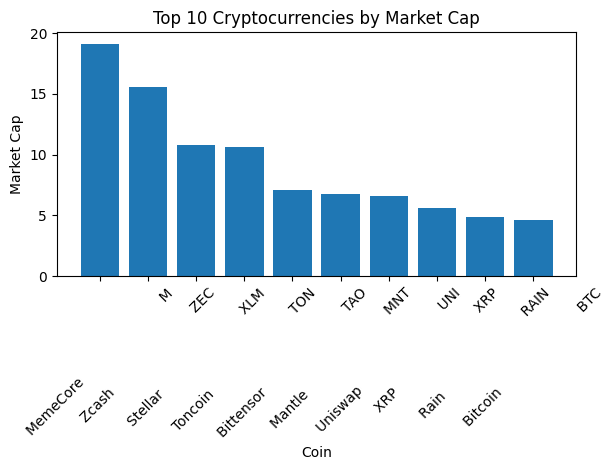

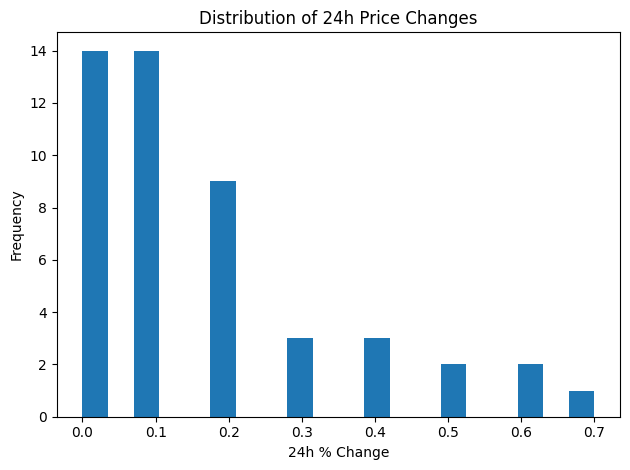

In [43]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Request page
# -------------------------------
url = "https://www.coingecko.com/en"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# -------------------------------
# Step 2: Extract data (FIXED)
# -------------------------------
rows = soup.find("tbody").find_all("tr")

data = []

for row in rows[:50]:
    cols = row.find_all("td")

    try:
        name = cols[2].text.strip().replace("\n", " ")
        price = cols[4].text.strip()
        change_24h = cols[5].text.strip()
        change_7d = cols[6].text.strip()

        # ✅ FIXED columns
        market_cap = cols[7].text.strip()
        volume = cols[8].text.strip()

        data.append({
            "name": name,
            "price": price,
            "24h_change": change_24h,
            "7d_change": change_7d,
            "market_cap": market_cap,
            "volume": volume
        })

    except:
        continue

df = pd.DataFrame(data)

# Save raw data
df.to_csv("coingecko_raw.csv", index=False)

print("RAW DATA:")
print(df.head())
print("Shape:", df.shape)

# -------------------------------
# Step 3: Clean data
# -------------------------------
def clean_column(col):
    return (
        col.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("\n", "", regex=False)
        .str.strip()
    )

df["price"] = pd.to_numeric(clean_column(df["price"]), errors="coerce")
df["market_cap"] = pd.to_numeric(clean_column(df["market_cap"]), errors="coerce")
df["volume"] = pd.to_numeric(clean_column(df["volume"]), errors="coerce")
df["24h_change"] = pd.to_numeric(clean_column(df["24h_change"]), errors="coerce")
df["7d_change"] = pd.to_numeric(clean_column(df["7d_change"]), errors="coerce")

# Drop invalid rows
df = df.dropna()

print("\nCLEANED DATA:")
print(df.head())
print("Shape:", df.shape)

# -------------------------------
# Step 4: Analysis
# -------------------------------

# Biggest gain
biggest_gain = df.loc[df["24h_change"].idxmax()]
print("\nBiggest 24h Gain:")
print(biggest_gain[["name", "24h_change"]])

# Biggest loss
biggest_loss = df.loc[df["24h_change"].idxmin()]
print("\nBiggest 24h Loss:")
print(biggest_loss[["name", "24h_change"]])

# Total market cap
total_market_cap = df["market_cap"].sum()
print(f"\nTotal Market Cap: {total_market_cap}")

# Coins down over 7 days
down_7d = df[df["7d_change"] < 0]
print(f"\nCoins down over 7 days: {len(down_7d)}")

# -------------------------------
# Step 5: Charts
# -------------------------------

# Chart 1: Top 10 by market cap
top10 = df.sort_values(by="market_cap", ascending=False).head(10)

plt.figure()
plt.bar(top10["name"], top10["market_cap"])
plt.title("Top 10 Cryptocurrencies by Market Cap")
plt.xlabel("Coin")
plt.ylabel("Market Cap")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: 24h change distribution
plt.figure()
plt.hist(df["24h_change"], bins=20)
plt.title("Distribution of 24h Price Changes")
plt.xlabel("24h % Change")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [31]:
private_df = pd.read_csv("private_companies.csv")

print(private_df.head())

   Name Country                         BTC       Value
0     1      🇺🇸                   Block.one  ₿\n164,000
1     2      🇻🇬     Tether Holdings Limited   ₿\n97,141
2     3      🇺🇸  Stone Ridge Holdings Group   ₿\n10,000
3     4      🇺🇸                 SpaceX\n🥬 🙌    ₿\n8,285
4     5      🇨🇭        The Tezos Foundation    ₿\n2,903


In [44]:


def clean_btc(col):
    return (
        col.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("BTC", "", regex=False)   # 🔥 THIS IS THE FIX
        .str.strip()
    )

public_df["BTC"] = pd.to_numeric(clean_btc(public_df["BTC"]), errors="coerce")
private_df["BTC"] = pd.to_numeric(clean_btc(private_df["BTC"]), errors="coerce")

In [ ]:
print(public_df["BTC"].head())
print(private_df["BTC"].head())

print("Public total:", public_df["BTC"].sum())
print("Private total:", private_df["BTC"].sum())

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: BTC, dtype: float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: BTC, dtype: float64
Public total: 0.0
Private total: 0.0


In [40]:
public_total = public_df["BTC"].sum()
private_total = private_df["BTC"].sum()

print("Public Total BTC:", public_total)
print("Private Total BTC:", private_total)

if public_total > private_total:
    print("Public companies hold more Bitcoin")
else:
    print("Private companies hold more Bitcoin")

Public Total BTC: 0.0
Private Total BTC: 0.0
Private companies hold more Bitcoin


In [34]:
common = set(public_df["Name"]).intersection(set(private_df["Name"]))

print("Companies in both lists:", len(common))
print(common)

Companies in both lists: 0
set()


In [35]:
combined = pd.concat([public_df, private_df])

country_counts = combined["Country"].value_counts()

print(country_counts.head())

top_country = country_counts.idxmax()
print("Country with most companies:", top_country)

Country
🇺🇸    102
🇨🇦     34
🇬🇧     21
🇯🇵     14
🇭🇰     10
Name: count, dtype: int64
Country with most companies: 🇺🇸


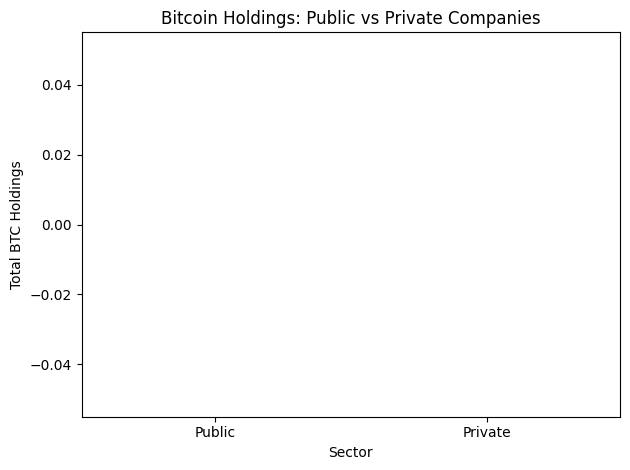

In [36]:
import matplotlib.pyplot as plt

labels = ["Public", "Private"]
values = [public_total, private_total]

plt.figure()
plt.bar(labels, values)
plt.title("Bitcoin Holdings: Public vs Private Companies")
plt.xlabel("Sector")
plt.ylabel("Total BTC Holdings")
plt.tight_layout()
plt.show()

In [ ]:
# PART 2

Public data:
  Name                            Country    BTC    Value
0    1                           Strategy   MSTR  780,897
1    2                 Twenty One Capital    XXI   43,514
2    3                    Metaplanet Inc.  MPJPY   40,177
3    4                MARA Holdings, Inc.   MARA   38,689
4    5  Bitcoin Standard Treasury Company   CEPO   30,021

Private data:
  Name Country         BTC     Value
0    1      🇺🇸  ₿\n164,000  $12,213M
1    2      🇻🇬   ₿\n97,141   $7,234M
2    3      🇺🇸   ₿\n10,000     $745M
3    4      🇺🇸    ₿\n8,285     $617M
4    5      🇨🇭    ₿\n2,903     $216M

Cleaned BTC values:
21     434.0
35    3659.0
37    3189.0
38    3825.0
51    6574.0
Name: BTC, dtype: float64

Public Total BTC: 857875.0
Private Total BTC: 0.0
Public companies hold more Bitcoin

Companies in both lists: 0
set()

Top countries:
Country
Boyaa Interactive International Limited    1
NEXON Co., Ltd.                            1
Anap Holdings Inc.                         1
Remixpoint 

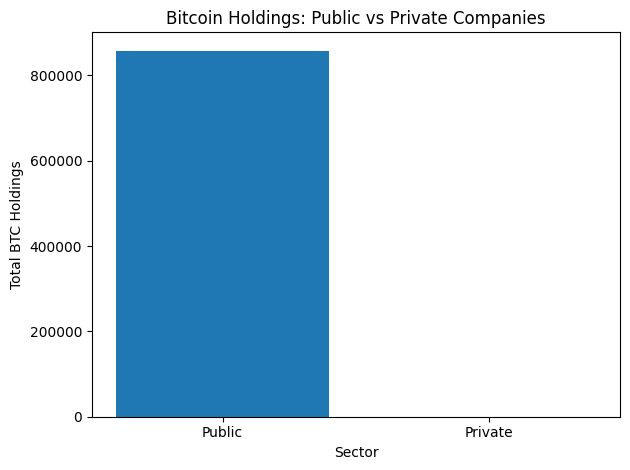

In [46]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: SCRAPE PUBLIC COMPANIES
# -------------------------------
driver = webdriver.Chrome()

url_public = "https://bitcointreasuries.net/public-companies"
driver.get(url_public)

wait = WebDriverWait(driver, 20)
wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "table tbody tr")))

time.sleep(3)

rows = driver.find_elements(By.CSS_SELECTOR, "table tbody tr")

public_data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")

    try:
        name = cols[0].text
        country = cols[1].text

        # ✅ FIXED COLUMN INDEX
        btc = cols[3].text
        value = cols[4].text

        public_data.append({
            "Name": name,
            "Country": country,
            "BTC": btc,
            "Value": value
        })

    except:
        continue

public_df = pd.DataFrame(public_data)
public_df.to_csv("public_companies.csv", index=False)

print("Public data:")
print(public_df.head())


# -------------------------------
# STEP 2: SCRAPE PRIVATE COMPANIES
# -------------------------------
url_private = "https://bitcointreasuries.net/private-companies"
driver.get(url_private)

wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "table tbody tr")))

time.sleep(3)

rows = driver.find_elements(By.CSS_SELECTOR, "table tbody tr")

private_data = []

for row in rows:
    cols = row.find_elements(By.TAG_NAME, "td")

    try:
        name = cols[0].text
        country = cols[1].text

        # ✅ SAME FIX HERE
        btc = cols[3].text
        value = cols[4].text

        private_data.append({
            "Name": name,
            "Country": country,
            "BTC": btc,
            "Value": value
        })

    except:
        continue

private_df = pd.DataFrame(private_data)
private_df.to_csv("private_companies.csv", index=False)

print("\nPrivate data:")
print(private_df.head())


# -------------------------------
# STEP 3: CLEAN BTC COLUMN
# -------------------------------
def clean_btc(col):
    return (
        col.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("BTC", "", regex=False)
        .str.strip()
    )

public_df["BTC"] = pd.to_numeric(clean_btc(public_df["BTC"]), errors="coerce")
private_df["BTC"] = pd.to_numeric(clean_btc(private_df["BTC"]), errors="coerce")

# Drop invalid rows
public_df = public_df.dropna(subset=["BTC"])
private_df = private_df.dropna(subset=["BTC"])

print("\nCleaned BTC values:")
print(public_df["BTC"].head())


# -------------------------------
# STEP 4: ANALYSIS
# -------------------------------

# Total BTC
public_total = public_df["BTC"].sum()
private_total = private_df["BTC"].sum()

print("\nPublic Total BTC:", public_total)
print("Private Total BTC:", private_total)

# Which sector holds more
if public_total > private_total:
    print("Public companies hold more Bitcoin")
else:
    print("Private companies hold more Bitcoin")

# Companies in both
common = set(public_df["Name"]).intersection(set(private_df["Name"]))
print("\nCompanies in both lists:", len(common))
print(common)

# Country with most companies
combined = pd.concat([public_df, private_df])
country_counts = combined["Country"].value_counts()

print("\nTop countries:")
print(country_counts.head())

print("Country with most companies:", country_counts.idxmax())


# -------------------------------
# STEP 5: CHART
# -------------------------------
labels = ["Public", "Private"]
values = [public_total, private_total]

plt.figure()
plt.bar(labels, values)
plt.title("Bitcoin Holdings: Public vs Private Companies")
plt.xlabel("Sector")
plt.ylabel("Total BTC Holdings")
plt.tight_layout()
plt.show()


# Close browser
driver.quit()